# T02 — GPlates Web Service (https://gws.gplates.org/) from Python: paleo-trajectories of modern cities

**Cluster A: paleo-reconstruction workflows.**

The [GPlates Web Service](https://gws.gplates.org/) (GWS) is an HTTP REST API
that executes plate reconstructions on a remote GPlates server, returning
results as JSON. The [`rgplates`](https://gplates.github.io/rgplates/) R
package (Kocsis et al. 2024) wraps GWS for R users; this notebook adapts the
same conceptual workflow to Python, hitting the GWS endpoints directly with
`requests`. No `pygplates` install is required for the GWS path — just an
internet connection and the service URL.

The notebook does three things:

1. **GWS-based backward reconstruction** — pick a set of modern cities,
   send their coordinates to GWS, get back paleo-positions through time.
2. **Local gplately comparison** — reconstruct the same points with the
   local `gplately` API using the same plate model, and check that the
   two paths agree (they should — both use the same rotation files
   internally).
3. **Trajectory visualisation** — plot each city's paleo-track on a
   pyGMT Robinson basemap, with the modern coastline overlaid as a
   reference frame.

## Audience
Recommended starting point for newcomers and undergraduates. Uses nothing beyond `requests` + `pandas` + `pygmt` for the GWS path (local `gplately` is only used for the cross-check in section 2), so it works in any Python install where `pygmt` builds — no `pygplates` install needed. Pairs well with T01 + T03 as a three-notebook introductory lab.

## Plate model
**Merdith 2021** (full Phanerozoic, the GWS default). Fetched via
`plate_model_manager` for the local comparison path.

## Learning objectives
1. Hit the GWS REST API directly from Python — no R, no pygplates wrapper
   layer required.
2. Parse the GWS JSON response into pandas DataFrames.
3. Reconstruct the same points with local `gplately` and verify the GWS
   and local paths return matching positions.
4. Plot paleo-trajectories as connected polylines on a pyGMT Robinson map.

## Prerequisites
- `requests`, `pandas`, `numpy`, `pygmt`, `gplately` (only for the local
  comparison path).
- Internet access for the GWS calls and for `plate_model_manager` first-run
  download of Merdith 2021.
- Runtime: ~30 s for the GWS calls; ~30-60 s for the local-gplately
  comparison; map render in seconds.

## Why this matters
For users who already work in Python this is just a `requests` workflow — no
new toolchain. For users who came from R via `rgplates (https://github.com/gplates/rgplates)`, this is the bridge:
the *same* GWS, accessed the same way, just from a different language.


## Configuration

In [6]:
# === USER CONFIGURATION =====================================================
from pathlib import Path
import os as _os
if Path("../data").exists() and not Path("data").exists():
    _os.chdir("..")

import numpy as np
import pandas as pd
import requests
import pygmt
import gplately
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

# ---- GPlates Web Service endpoint ------------------------------------------
GWS_BASE          = "https://gws.gplates.org"
GWS_RECONSTRUCT   = f"{GWS_BASE}/reconstruct/reconstruct_points/"

# ---- Plate model (GWS default is MERDITH2021) ------------------------------
GWS_MODEL_NAME    = "MERDITH2021"
LOCAL_MODEL_NAME  = "Merdith2021"      # plate_model_manager identifier
ANCHOR_PLATE_ID   = 0                  # spin-axis frame

# ---- Cities + reconstruction times -----------------------------------------
CITIES = pd.DataFrame([
    ("London",         51.5074,   -0.1278),
    ("Sydney",        -33.8688,  151.2093),
    ("Tokyo",          35.6762,  139.6503),
    ("New York",       40.7128,  -74.0060),
    ("Buenos Aires",  -34.6037,  -58.3816),
    ("Cape Town",     -33.9249,   18.4241),
    ("Mumbai",         19.0760,   72.8777),
], columns=["name", "lat", "lon"])

RECON_TIMES       = np.arange(0, 251, 10)   # 0-250 Ma at 10 Myr cadence
SNAPSHOT_TIME     = 100                     # Ma — used for the static map

# Save high-res copies of every figure to disk
SAVE_FIG_DIR      = Path("rgplates_pyfigs")
SAVE_FIG_DIR.mkdir(parents=True, exist_ok=True)
# ============================================================================
print(f"  GWS endpoint:   {GWS_RECONSTRUCT}")
print(f"  GWS model:      {GWS_MODEL_NAME}")
print(f"  local model:    {LOCAL_MODEL_NAME}")
print(f"  cities:         {list(CITIES.name)}")
print(f"  recon times:    {len(RECON_TIMES)} snapshots, 0-{int(RECON_TIMES.max())} Ma")


  GWS endpoint:   https://gws.gplates.org/reconstruct/reconstruct_points/
  GWS model:      MERDITH2021
  local model:    Merdith2021
  cities:         ['London', 'Sydney', 'Tokyo', 'New York', 'Buenos Aires', 'Cape Town', 'Mumbai']
  recon times:    26 snapshots, 0-250 Ma


## 1. Reconstruct points via the GPlates Web Service (https://gws.gplates.org/)

The GWS endpoint `/reconstruct/reconstruct_points/` accepts a `points` query
parameter (lon/lat pairs as `"lon1,lat1,lon2,lat2,..."`), a `time` parameter
in Ma, an `anchor_plate_id`, and a `model` identifier. The response is a
JSON object with a `coordinates` list — paleo-lon/paleo-lat pairs in the
same order as the input.

This is exactly the call that `rgplates (https://github.com/gplates/rgplates)::reconstruct()` makes from R.


In [7]:
# Section 1 — GWS reconstruction loop
import time as _time_mod

def _gws_get_with_retry(url, params, max_tries=4, base_timeout=120):
    """GET against GWS with exponential backoff. The public GWS service
    can be slow under load — retry transient timeouts before giving up."""
    last_exc = None
    for attempt in range(1, max_tries + 1):
        try:
            r = requests.get(url, params=params, timeout=base_timeout)
            r.raise_for_status()
            return r
        except (requests.exceptions.ReadTimeout,
                requests.exceptions.ConnectionError,
                requests.exceptions.HTTPError) as e:
            last_exc = e
            if attempt < max_tries:
                wait = 2 ** (attempt - 1) * 2   # 2, 4, 8, 16 s
                print(f"    GWS attempt {attempt}/{max_tries} failed ({type(e).name}); "
                      f"sleeping {wait}s before retry")
                _time_mod.sleep(wait)
    raise RuntimeError(f"GWS failed after {max_tries} tries: {last_exc}")


def gws_reconstruct(points_df, time, model=GWS_MODEL_NAME, anchor=ANCHOR_PLATE_ID):
    """Reconstruct (lon, lat) points to `time` Ma using GWS. Returns a copy
    of the input DataFrame with extra columns rlon/rlat."""
    pts_str = ",".join(f"{r.lon},{r.lat}" for r in points_df.itertuples())
    params  = dict(points=pts_str, time=float(time),
                   model=model, anchor_plate_id=int(anchor))
    r = _gws_get_with_retry(GWS_RECONSTRUCT, params)
    coords = r.json()["coordinates"]
    out = points_df.copy()
    out["rlon"] = [c[0] for c in coords]
    out["rlat"] = [c[1] for c in coords]
    out["time"] = float(time)
    return out

print(f"  reconstructing {len(CITIES)} cities at {len(RECON_TIMES)} times via GWS ...")
print(f"  (GWS calls have a 4-attempt retry with backoff if the service is slow)")
gws_rows = []
for t in RECON_TIMES:
    snap = gws_reconstruct(CITIES, t)
    gws_rows.append(snap)
gws_df = pd.concat(gws_rows, ignore_index=True)
print(f"  done — {len(gws_df)} rows")
print(gws_df.head(8).to_string(index=False))


  reconstructing 7 cities at 26 times via GWS ...
  (GWS calls have a 4-attempt retry with backoff if the service is slow)
  done — 182 rows
        name      lat      lon     rlon     rlat  time
      London  51.5074  -0.1278  -0.1278  51.5074   0.0
      Sydney -33.8688 151.2093 151.2093 -33.8688   0.0
       Tokyo  35.6762 139.6503 139.6503  35.6762   0.0
    New York  40.7128 -74.0060 -74.0060  40.7128   0.0
Buenos Aires -34.6037 -58.3816 -58.3816 -34.6037   0.0
   Cape Town -33.9249  18.4241  18.4241 -33.9249   0.0
      Mumbai  19.0760  72.8777  72.8777  19.0760   0.0
      London  51.5074  -0.1278  -0.1915  46.7451  10.0


## 2. Reconstruct the same points with local gplately

If both paths use the same Merdith 2021 rotation files, the GWS (https://gws.gplates.org/) and local
results should be effectively identical to within rounding. This is a useful
sanity check — it verifies your local `plate_model_manager` cache matches
what's behind the GWS, and it gives confidence to mix the two paths within
the same workflow (e.g. GWS for one-off queries, local for batch sweeps).


In [8]:
# Section 2 — local gplately reconstruction of the same points
pmm   = PlateModelManager()
model = pmm.get_model(LOCAL_MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    static_polygons=model.get_static_polygons())

pts = gplately.Points(recon, CITIES["lon"].to_numpy(), CITIES["lat"].to_numpy(),
                      anchor_plate_id=ANCHOR_PLATE_ID)

print(f"  reconstructing same {len(CITIES)} cities at {len(RECON_TIMES)} times via gplately ...")
local_rows = []
for t in RECON_TIMES:
    rlons, rlats = pts.reconstruct(float(t), return_array=True,
                                   anchor_plate_id=ANCHOR_PLATE_ID)
    df = CITIES.copy()
    df["rlon"] = rlons
    df["rlat"] = rlats
    df["time"] = float(t)
    local_rows.append(df)
local_df = pd.concat(local_rows, ignore_index=True)

# Cross-check: per-row great-circle distance between GWS and local paleo-positions
def gc_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    phi1, phi2 = np.deg2rad(lat1), np.deg2rad(lat2)
    dphi   = np.deg2rad(lat2 - lat1)
    dlam   = np.deg2rad(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

merge = gws_df.merge(local_df, on=["name", "lat", "lon", "time"],
                     suffixes=("_gws", "_loc"))
merge["sep_km"] = gc_km(merge.rlon_gws, merge.rlat_gws,
                        merge.rlon_loc, merge.rlat_loc)
print(f"\n  GWS vs local mean separation = {merge.sep_km.mean():.2f} km  "
      f"max = {merge.sep_km.max():.2f} km")
print(f"  (if both paths use the same rotation files, this should be sub-km)")


  reconstructing same 7 cities at 26 times via gplately ...

  GWS vs local mean separation = 0.00 km  max = 0.01 km
  (if both paths use the same rotation files, this should be sub-km)


## 3. Paleo-trajectory map (pyGMT)

Each city gets a polyline traced through its paleo-positions, plus circle markers at every 50 Myr tick. Coastlines + a `Robinson` basemap provide the modern reference frame.

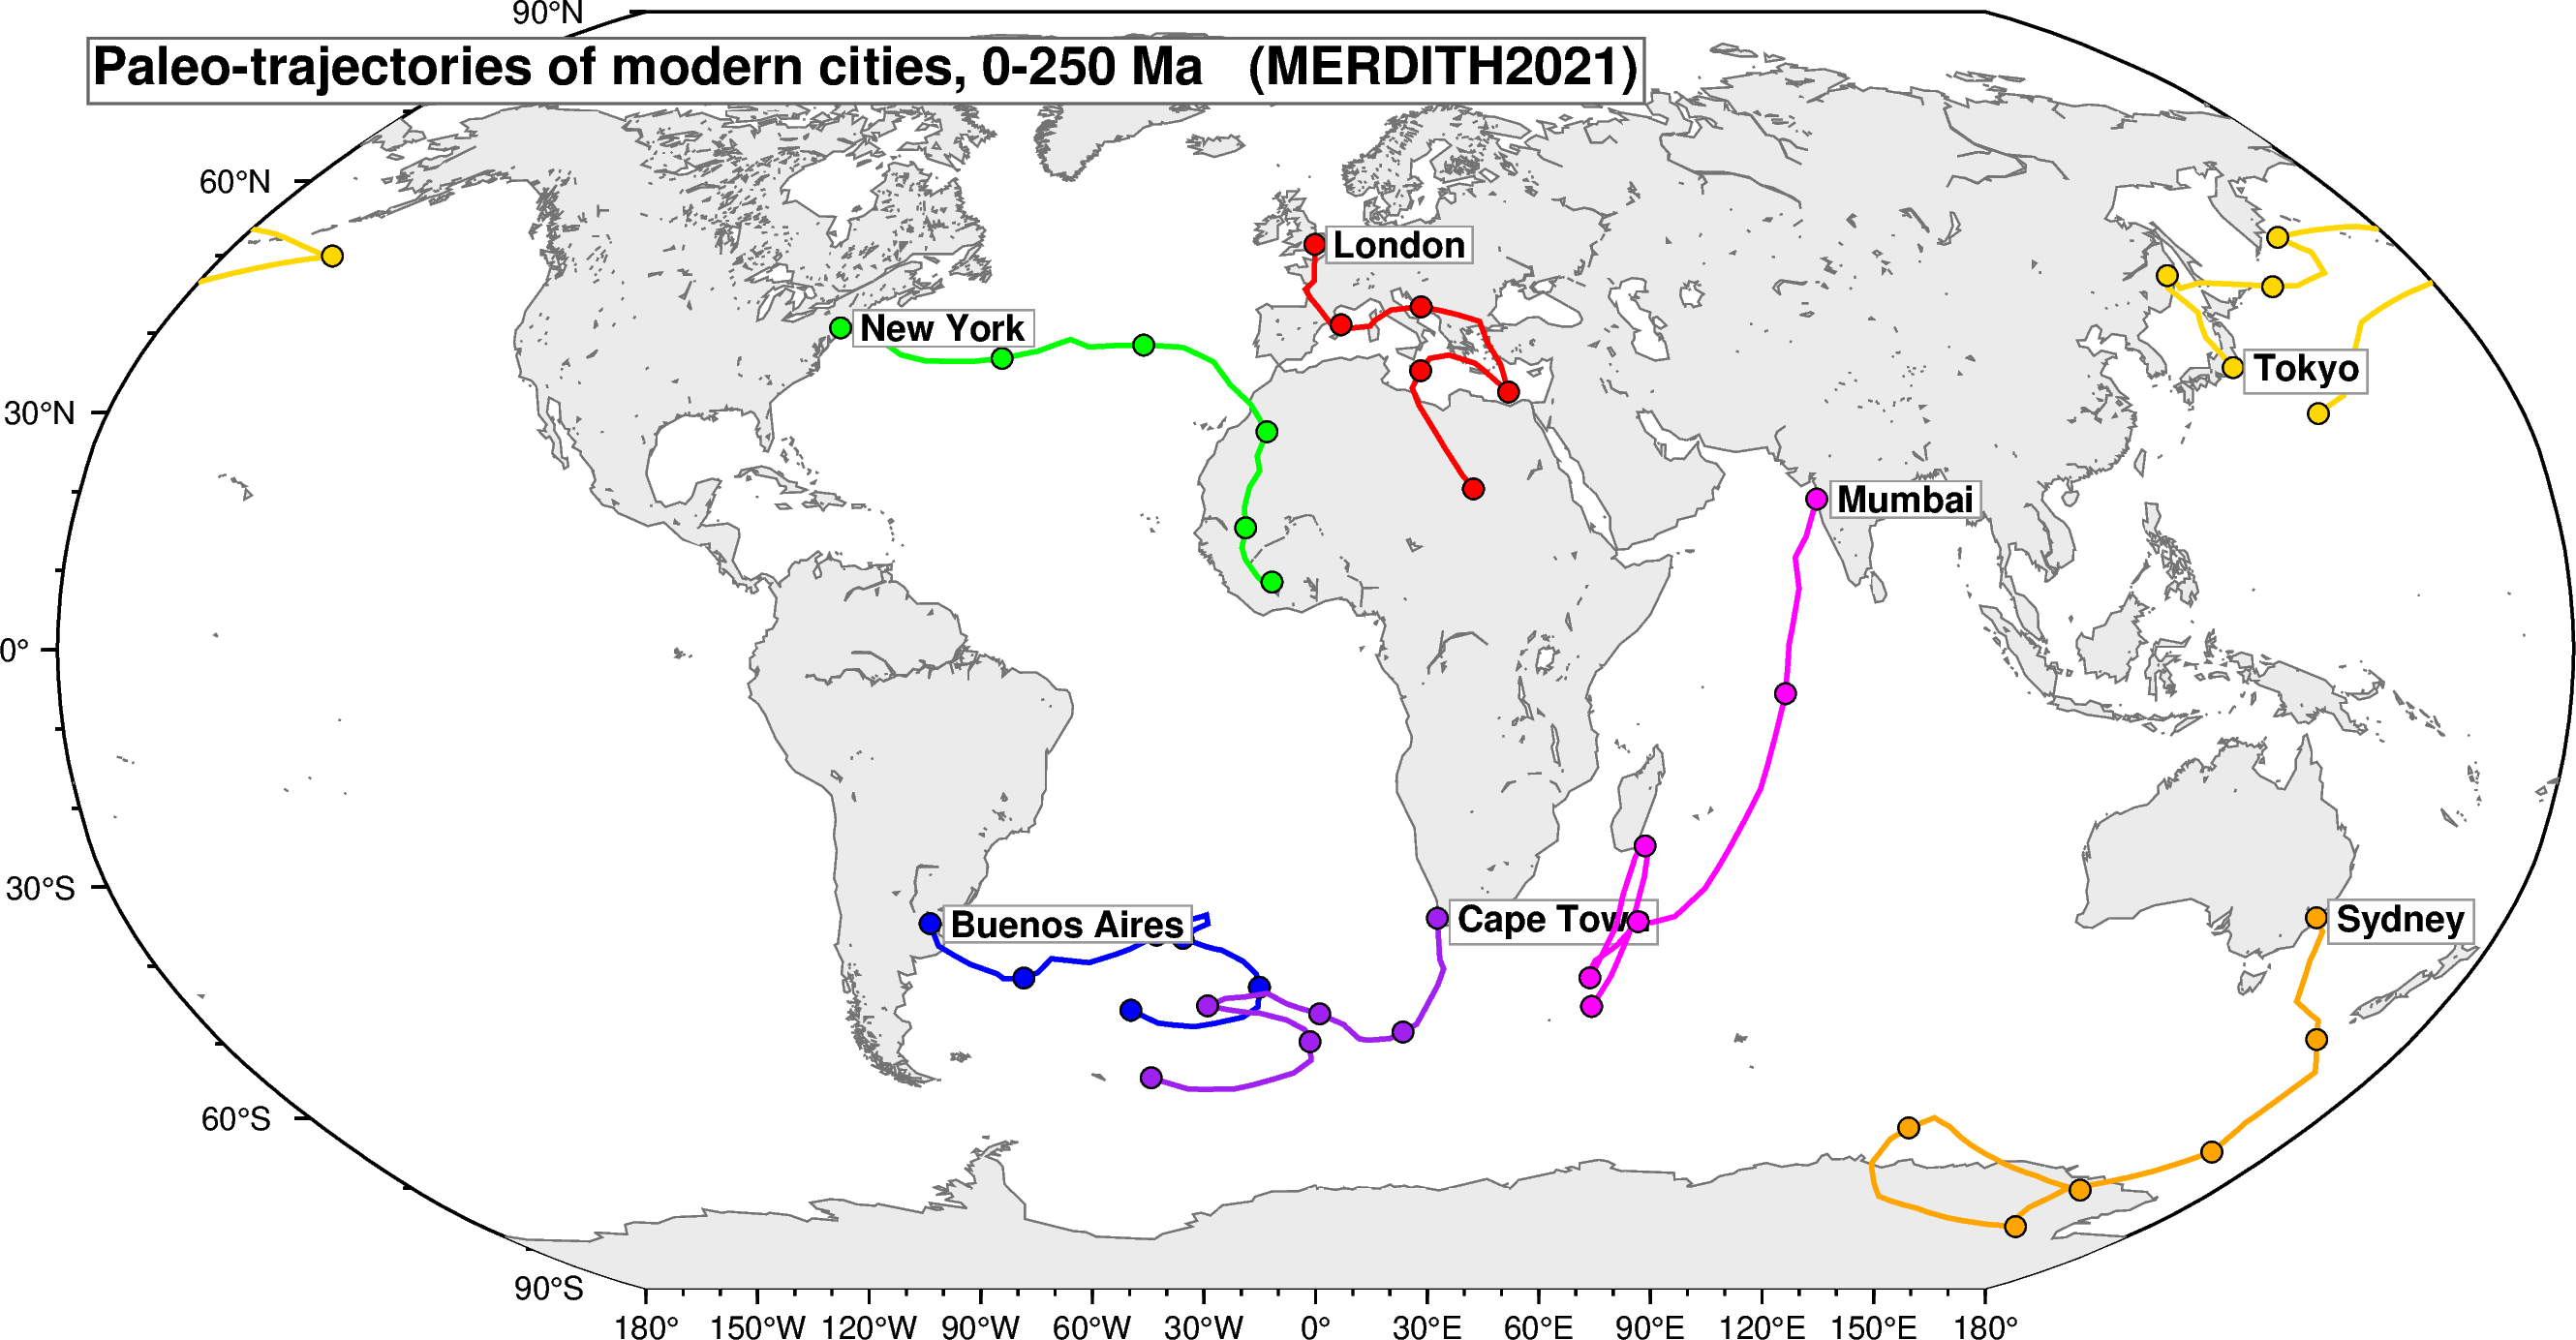

  saved: rgplates_pyfigs/T45_paleo_trajectories.png


In [9]:
# Section 3 — pyGMT paleo-trajectory map
city_colors = pygmt.makecpt(cmap="categorical", series=[0, len(CITIES), 1])
fig = pygmt.Figure()
fig.basemap(region="d", projection="N0/22c", frame=["af"])
fig.coast(land="gray92", shorelines="0.4p,gray45")

# Per-city polyline + marker dots
COLORS = ["red", "orange", "gold", "green", "blue", "purple", "magenta"]
for j, name in enumerate(CITIES.name):
    track = gws_df[gws_df.name == name].sort_values("time")
    color = COLORS[j % len(COLORS)]
    # trajectory line
    fig.plot(x=track.rlon.to_numpy(),
             y=track.rlat.to_numpy(),
             pen=f"1.2p,{color}")
    # 50-Myr tick markers
    ticks = track[track.time % 50 == 0]
    fig.plot(x=ticks.rlon.to_numpy(),
             y=ticks.rlat.to_numpy(),
             style="c0.18c", fill=color, pen="0.4p,black")
    # present-day position label
    today = track[track.time == 0]
    if len(today):
        fig.text(x=today.rlon.values[0] + 3,
                 y=today.rlat.values[0],
                 text=name,
                 font="9p,Helvetica-Bold,black",
                 justify="ML", fill="white", pen="0.4p,gray60",
                 clearance="0.08c/0.04c+to")

fig.text(text=f"Paleo-trajectories of modern cities, 0-{int(RECON_TIMES.max())} Ma   ({GWS_MODEL_NAME})",
         position="TL", offset="0.3c/-0.3c", justify="TL",
         font="13p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
out = SAVE_FIG_DIR / "T45_paleo_trajectories.png"
fig.savefig(out, dpi=200)
fig.show(width=1200)
display(HTML('<div style="height:1cm"></div>'))
print(f"  saved: {out}")


## 4. Snapshot map at {snapshot} Ma

A second pyGMT figure showing all cities at a single snapshot time, on top
of the reconstructed coastlines fetched from GWS (https://gws.gplates.org/) for the same model + time.
This is the GWS-only path — no `pygplates`, no local plate-model files.


  fetching GWS coastlines at 100 Ma ...
    got 2451 coastline features


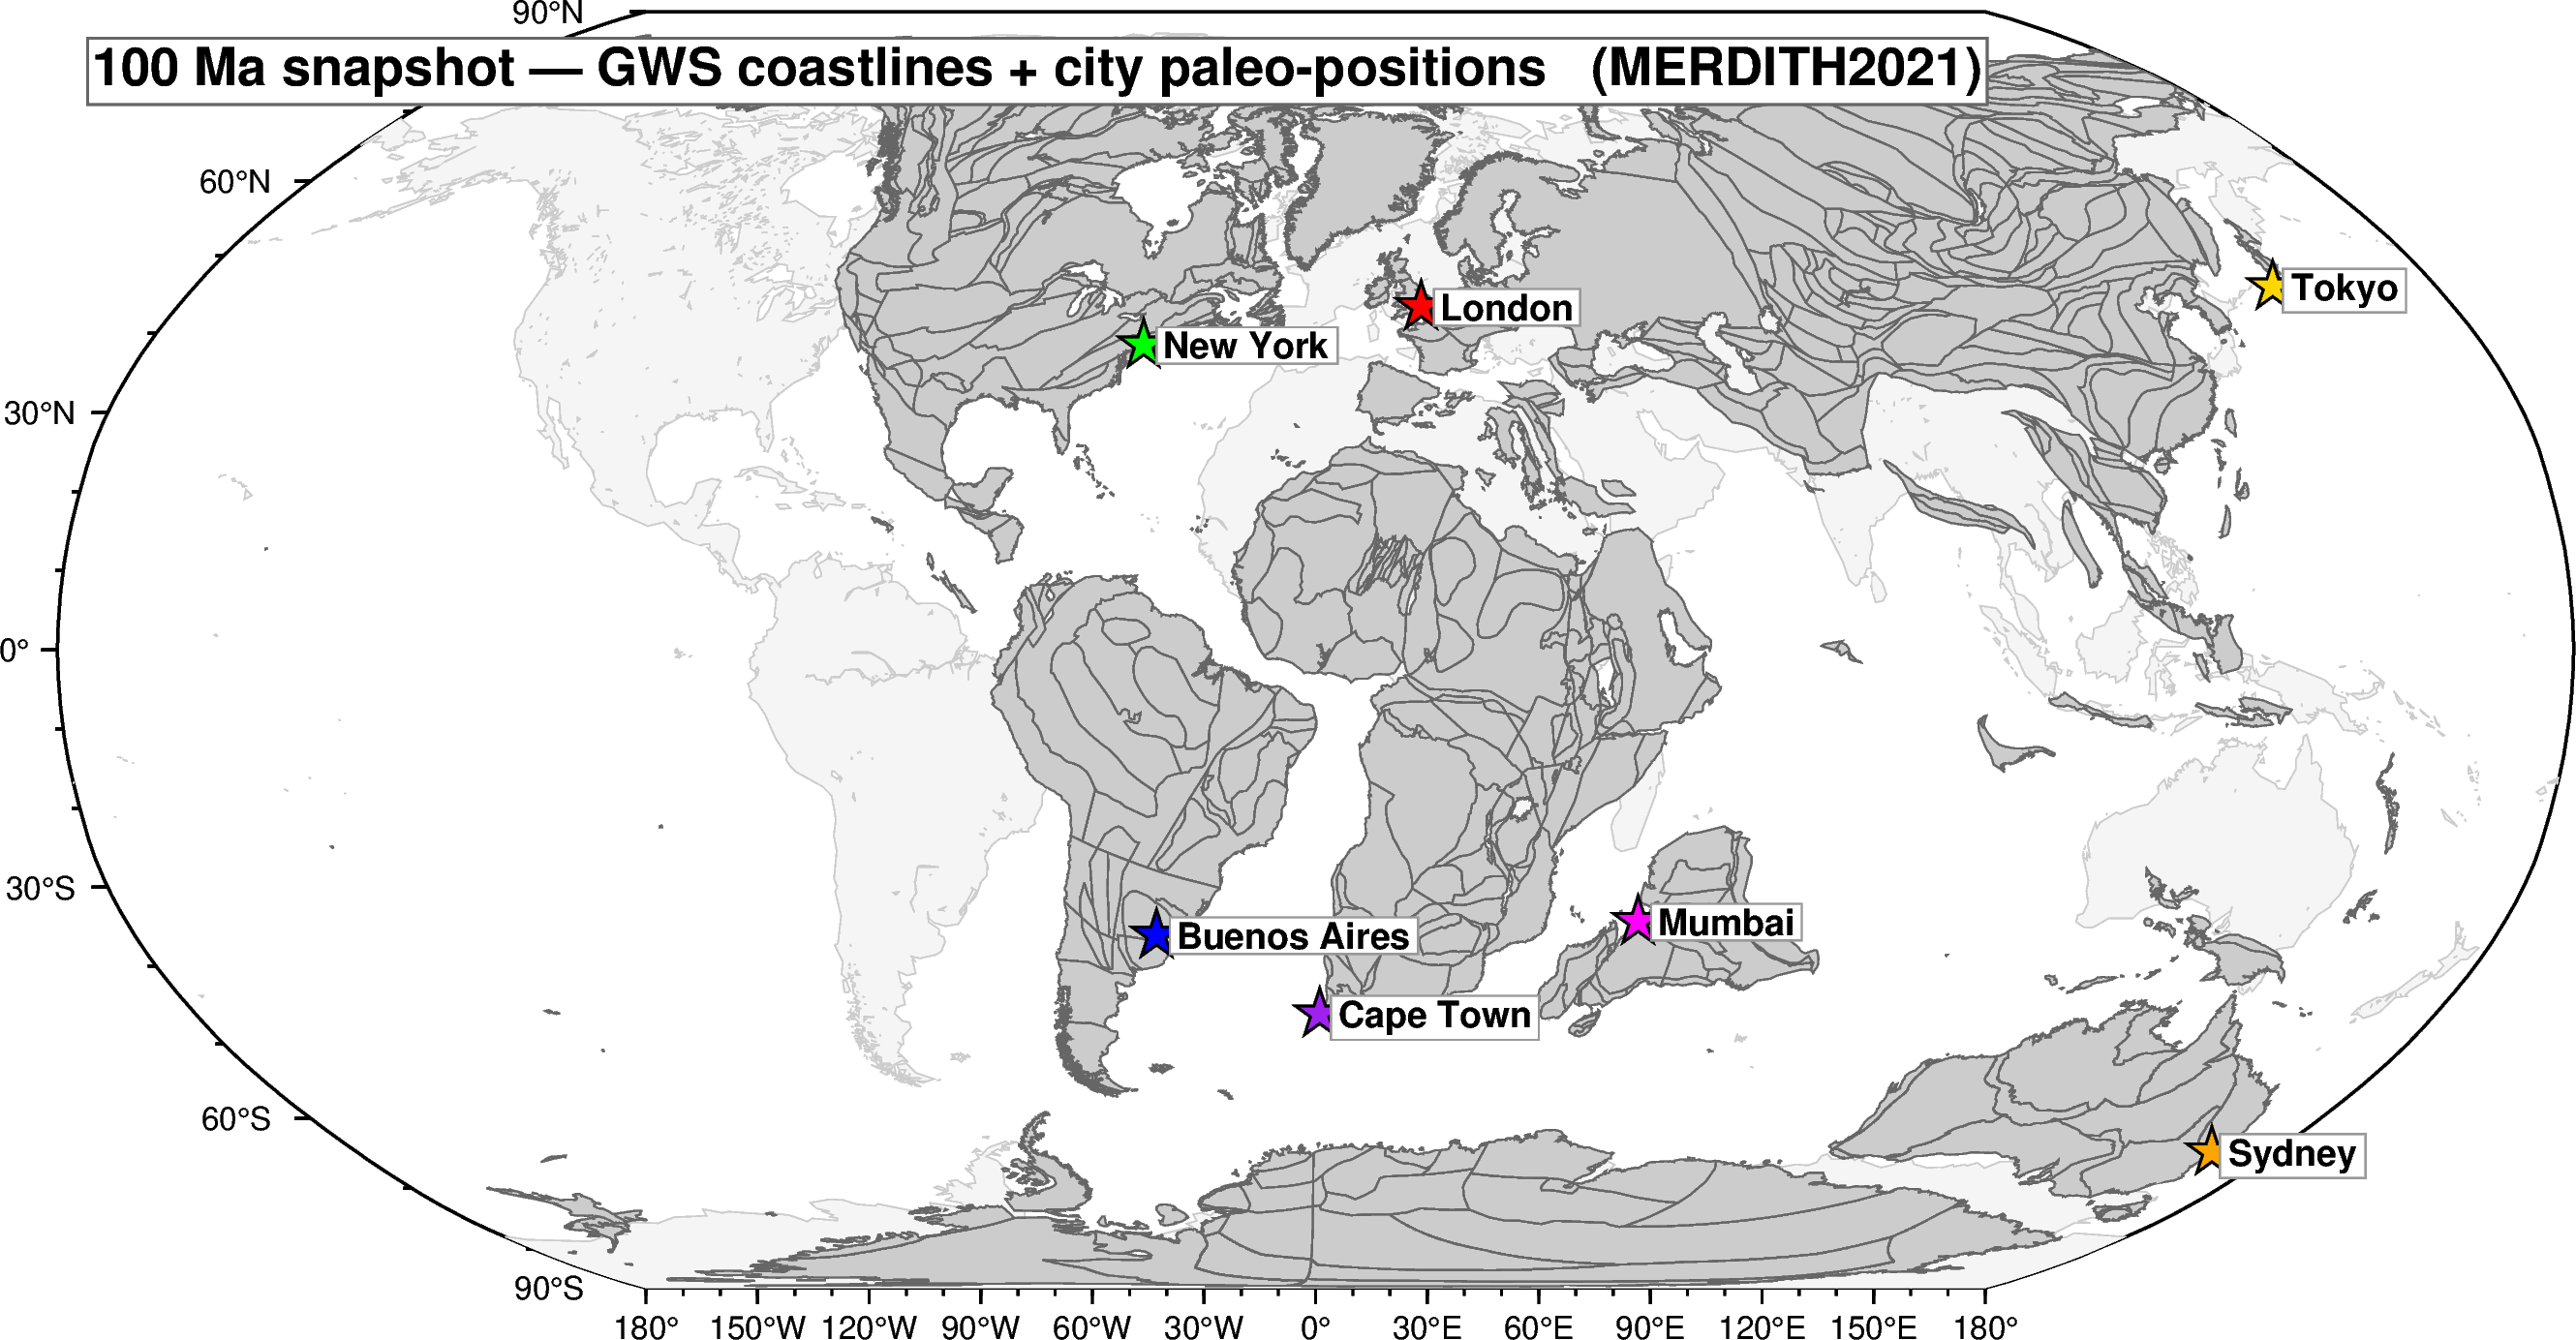

  saved: rgplates_pyfigs/T45_snapshot_100Ma.png


In [10]:
# Section 4 — snapshot + GWS coastlines at SNAPSHOT_TIME
def gws_coastlines(time, model=GWS_MODEL_NAME, anchor=ANCHOR_PLATE_ID):
    """Fetch reconstructed coastlines as GeoJSON from GWS, with retries."""
    url = f"{GWS_BASE}/reconstruct/coastlines/"
    params = dict(time=float(time), model=model, anchor_plate_id=int(anchor))
    r = _gws_get_with_retry(url, params, base_timeout=180)
    return r.json()

print(f"  fetching GWS coastlines at {SNAPSHOT_TIME} Ma ...")
gj = gws_coastlines(SNAPSHOT_TIME)
n_feat = len(gj.get("features", []))
print(f"    got {n_feat} coastline features")

# Get this snapshot's city positions
snap = gws_df[gws_df.time == SNAPSHOT_TIME].copy()

fig = pygmt.Figure()
fig.basemap(region="d", projection="N0/22c", frame=["af"])
# present-day coastline as a pale reference
fig.coast(land="gray96", shorelines="0.3p,gray80")
# overlay the reconstructed coastlines from GWS
# Direct ring-by-ring plotting — robust to GeoJSON features without a
# 'properties' key (geopandas.GeoDataFrame.from_features requires it).
for feat in gj["features"]:
    geom = feat["geometry"]
    if geom["type"] == "Polygon":
        ring = geom["coordinates"][0]
        fig.plot(x=[pt[0] for pt in ring],
                 y=[pt[1] for pt in ring],
                 fill="gray80", pen="0.4p,gray40", close=True)
    elif geom["type"] == "MultiPolygon":
        for poly in geom["coordinates"]:
            ring = poly[0]
            fig.plot(x=[pt[0] for pt in ring],
                     y=[pt[1] for pt in ring],
                     fill="gray80", pen="0.4p,gray40", close=True)

# overlay the snapshot city positions
for j, row in enumerate(snap.itertuples()):
    color = COLORS[j % len(COLORS)]
    fig.plot(x=row.rlon, y=row.rlat,
             style="a0.45c", fill=color, pen="0.6p,black")
    fig.text(x=row.rlon + 3, y=row.rlat, text=row.name,
             font="9p,Helvetica-Bold,black", justify="ML",
             fill="white", pen="0.4p,gray60",
             clearance="0.08c/0.04c+to")

fig.text(text=f"{SNAPSHOT_TIME} Ma snapshot — GWS coastlines + city paleo-positions   ({GWS_MODEL_NAME})",
         position="TL", offset="0.3c/-0.3c", justify="TL",
         font="13p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
out = SAVE_FIG_DIR / f"T45_snapshot_{SNAPSHOT_TIME}Ma.png"
fig.savefig(out, dpi=200)
fig.show(width=1200)
display(HTML('<div style="height:1cm"></div>'))
print(f"  saved: {out}")


## What this notebook demonstrates

The GPlates Web Service (https://gws.gplates.org/) exposes the same rotation engine that `pygplates` and
`gplately` use locally — just over HTTP. Either path is equally valid; the
trade-off is between speed (local is faster for batches) and convenience
(GWS needs no install). The cross-check in section 2 confirms the two paths
agree to sub-kilometre precision when given the same model and anchor.

For R users discovering this from the `rgplates (https://github.com/gplates/rgplates)` documentation, the takeaway
is that the same workflow ports to Python with one `requests.get` per call.
No R-Python interop needed.

## Extend this
- Add `pygplates` as a third path and compare all three on the same points.
  This isolates whether any disagreement is in the rotation files (would
  affect all three the same way) vs the wrapper layer.
- Swap `GWS_MODEL_NAME` for other GWS-supported models (`SCOTESE`,
  `MULLER2019`, etc.) — see the GWS docs for the current list.
- Extend the trajectory map back to the full Phanerozoic (540 Ma) — note
  that not every model in the GWS catalogue covers that range; Merdith 2021
  is the safe default for deep time.
- Drive `gws_reconstruct` from a large CSV of localities (fossil occurrences,
  ore deposits, sample sites) to produce a per-site paleo-position table
  without ever loading a plate model locally.

## Source
- Kocsis, A.T., Raja, N.B. (2024). *rgplates: R interface for the GPlates
  Web Service.* GitHub: https://github.com/gplates/rgplates.
- GPlates Web Service: https://gws.gplates.org/, docs at
  https://gwsdoc.gplates.org/.
- Merdith, A.S. et al. (2021). *Extending full-plate tectonic models into
  deep time: linking the Neoproterozoic and the Phanerozoic.*
  Earth-Science Reviews 214, 103477.
